# Sentiment Analysis of Restaurant Reviews using NLP and Machine Learning

**Dataset**: Yelp Restaurant Reviews  
**Models**: Naive Bayes | Logistic Regression | SVM  
**Workflow**: Text Preprocessing → TF-IDF → ML Classification → Evaluation

## 0. Import Libraries

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

import nltk
for res in ['punkt','punkt_tab','stopwords','wordnet','omw-1.4']:
    nltk.download(res, quiet=True)

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

plt.rcParams.update({'font.family': 'DejaVu Sans', 'axes.spines.top': False, 'axes.spines.right': False})
print('Libraries loaded successfully!')

Libraries loaded successfully!


---
## 1. Load Dataset

In [2]:
DATA_PATH = os.path.join(os.getcwd(), 'data', 'raw', 'yelp_sentiment_master_dataset.csv')
df_raw = pd.read_csv(DATA_PATH, on_bad_lines='skip')
df_raw = df_raw.rename(columns={'rating_review': 'sentiment'})
df_raw = df_raw[['text', 'sentiment']].dropna()
df_raw = df_raw[df_raw['sentiment'].isin(['Positive', 'Neutral', 'Negative'])]
df_raw = df_raw[df_raw['text'].str.strip().str.len() > 0].reset_index(drop=True)

print(f'Total usable reviews: {len(df_raw):,}')
df_raw.head(3)

Total usable reviews: 14,351


,text,sentiment
0,"If you decide to eat here, just be aware it is...",Neutral
1,Family diner. Had the buffet. Eclectic assortm...,Neutral
2,"Wow! Yummy, different, delicious. Our favo...",Positive


---
## 2. Sentiment Distribution

Sampled: 10,000 reviews
sentiment
Positive    6868
Negative    1881
Neutral     1251
Name: count, dtype: int64


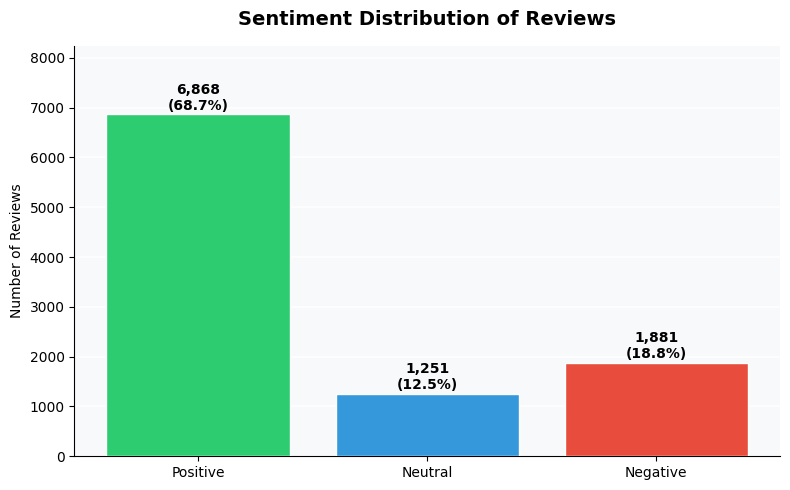

In [3]:
# Stratified sample of 10,000
df = df_raw.groupby('sentiment', group_keys=False).apply(
    lambda x: x.sample(frac=10000/len(df_raw), random_state=42)
).sample(n=min(10000, len(df_raw)), random_state=42).reset_index(drop=True)

print(f'Sampled: {len(df):,} reviews')
print(df['sentiment'].value_counts())

COLORS = {'Positive': '#2ecc71', 'Neutral': '#3498db', 'Negative': '#e74c3c'}
counts = df['sentiment'].value_counts()
labels = ['Positive', 'Neutral', 'Negative']
values = [counts.get(l, 0) for l in labels]
total  = sum(values)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values, color=[COLORS[l] for l in labels], edgecolor='white', zorder=3)
ax.set_facecolor('#f8f9fa')
ax.grid(axis='y', color='white', linewidth=1.2, zorder=2)
ax.set_title('Sentiment Distribution of Reviews', fontweight='bold', pad=15, fontsize=14)
ax.set_ylabel('Number of Reviews')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:,}\n({val/total*100:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylim(0, max(values)*1.2)
plt.tight_layout()
plt.show()

---
## 3. Text Preprocessing

In [4]:
import re
STOPWORDS  = set(stopwords.words('english')) - {'not','no','never','nor','neither','without'}
LEMMATIZER = WordNetLemmatizer()

def clean_text(text):
    if not isinstance(text, str): return ''
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    tokens = [LEMMATIZER.lemmatize(t) for t in tokens if t not in STOPWORDS and len(t) > 1]
    return ' '.join(tokens)

print('Preprocessing text...')
df['cleaned_text'] = df['text'].apply(clean_text)
df = df[df['cleaned_text'].str.strip().str.len() > 0].reset_index(drop=True)
print(f'Done! {len(df):,} reviews ready.')

# Example
idx = 0
print(f'\nOriginal : {df["text"].iloc[idx][:120]}...')
print(f'Cleaned  : {df["cleaned_text"].iloc[idx][:120]}...')

Preprocessing text...
Done! 10,000 reviews ready.

Original : My first time to La Fusion, on my way to the mall, decided to grab a bite first. Great food, great service, very beautif...
Cleaned  : first time la fusion way mall decided grab bite first great food great service beautiful restaurant setup clean restaura...


---
## 4. Word Cloud by Sentiment

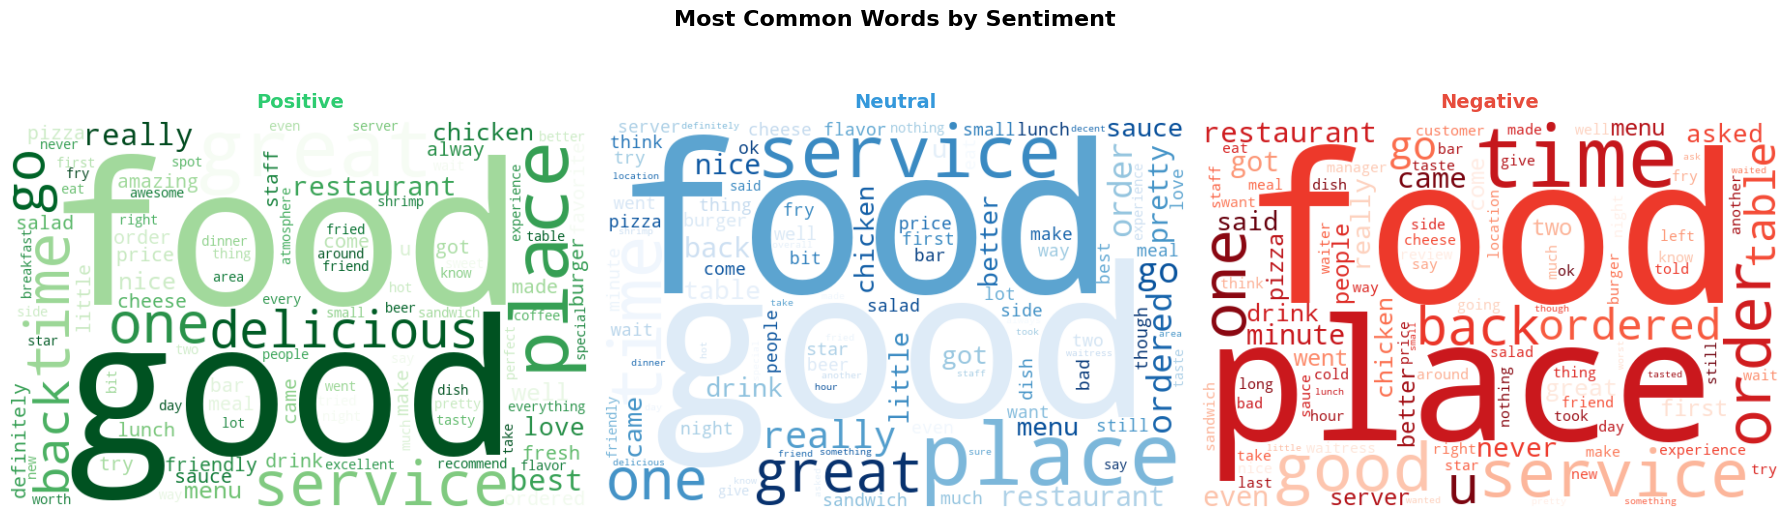

In [5]:
WCMAP = {'Positive': 'Greens', 'Neutral': 'Blues', 'Negative': 'Reds'}
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Most Common Words by Sentiment', fontsize=16, fontweight='bold')

for ax, label in zip(axes, ['Positive', 'Neutral', 'Negative']):
    text = ' '.join(df[df['sentiment'] == label]['cleaned_text'].tolist())
    wc = WordCloud(width=600, height=400, background_color='white',
                   colormap=WCMAP[label], max_words=100, collocations=False).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(label, fontsize=14, fontweight='bold', color=COLORS[label], pad=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

---
## 5. Feature Extraction (TF-IDF)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_text'].tolist(), df['sentiment'].tolist(),
    test_size=0.20, stratify=df['sentiment'], random_state=42
)
print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')

vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2),
                              sublinear_tf=True, min_df=2, max_df=0.95)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)
print(f'Feature matrix shape → Train: {X_train_tfidf.shape}, Test: {X_test_tfidf.shape}')

Train: 8,000  |  Test: 2,000
Feature matrix shape → Train: (8000, 10000), Test: (2000, 10000)


---
## 6. Train Machine Learning Models

In [8]:
models = {
    'Naive Bayes'        : MultinomialNB(alpha=0.1),
    'Logistic Regression': LogisticRegression(C=5.0, max_iter=1000, solver='lbfgs', random_state=42, n_jobs=-1),
    'SVM'                : CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=2000, random_state=42), cv=3),
}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    print(f'[OK] {name} trained')

[OK] Naive Bayes trained
[OK] Logistic Regression trained
[OK] SVM trained


---
## 7. Evaluate Models

In [9]:
results = {}
rows = []

for name, model in models.items():
    y_pred = model.predict(X_test_tfidf)
    results[name] = {'y_pred': y_pred, 'y_true': y_test}
    rows.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, average='weighted', zero_division=0), 4),
        'Recall'   : round(recall_score(y_test, y_pred, average='weighted', zero_division=0), 4),
        'F1-Score' : round(f1_score(y_test, y_pred, average='weighted', zero_division=0), 4),
    })

comparison_df = pd.DataFrame(rows).set_index('Model')
comparison_df.style.highlight_max(color='#d4f1d4', axis=0)

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Naive Bayes,0.816500,0.786200,0.816500,0.780700
Logistic Regression,0.835500,0.812800,0.835500,0.819200
SVM,0.833500,0.801500,0.833500,0.805700


---
## 8. Model Comparison Chart

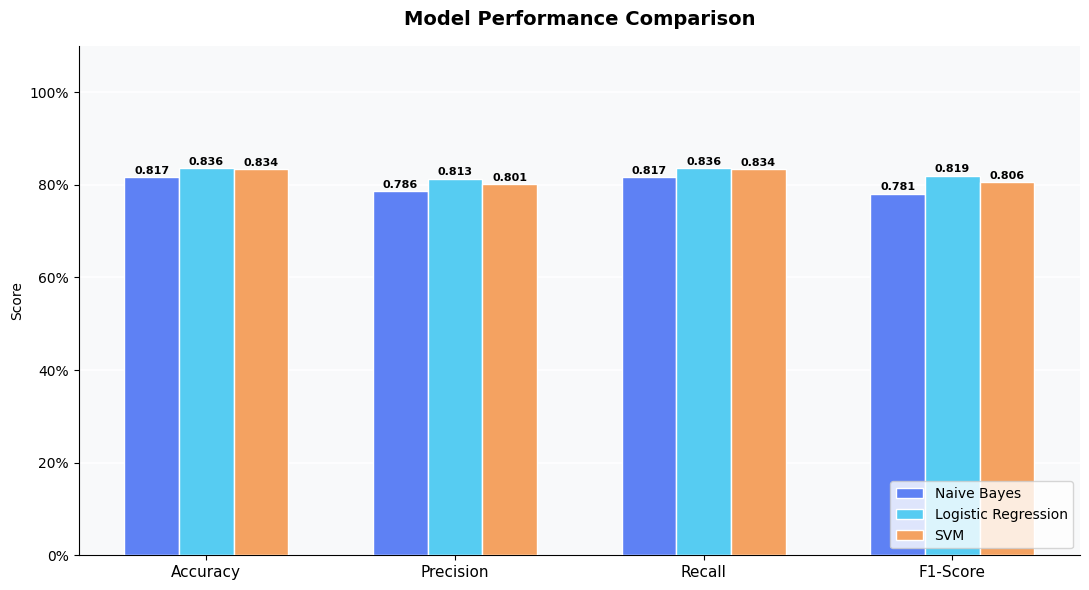

In [10]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
model_names = comparison_df.index.tolist()
x = np.arange(len(metrics))
width = 0.22
MODEL_COLORS = ['#5e81f4', '#56ccf2', '#f4a261']

fig, ax = plt.subplots(figsize=(11, 6))
ax.set_facecolor('#f8f9fa')
ax.grid(axis='y', color='white', linewidth=1.2, zorder=2)

for i, (model, color) in enumerate(zip(model_names, MODEL_COLORS)):
    vals = [comparison_df.loc[model, m] for m in metrics]
    offset = (i - 1) * width
    bars = ax.bar(x + offset, vals, width, label=model, color=color, edgecolor='white', zorder=3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_title('Model Performance Comparison', fontweight='bold', pad=15, fontsize=14)
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

---
## 9. Per-Class F1 Score

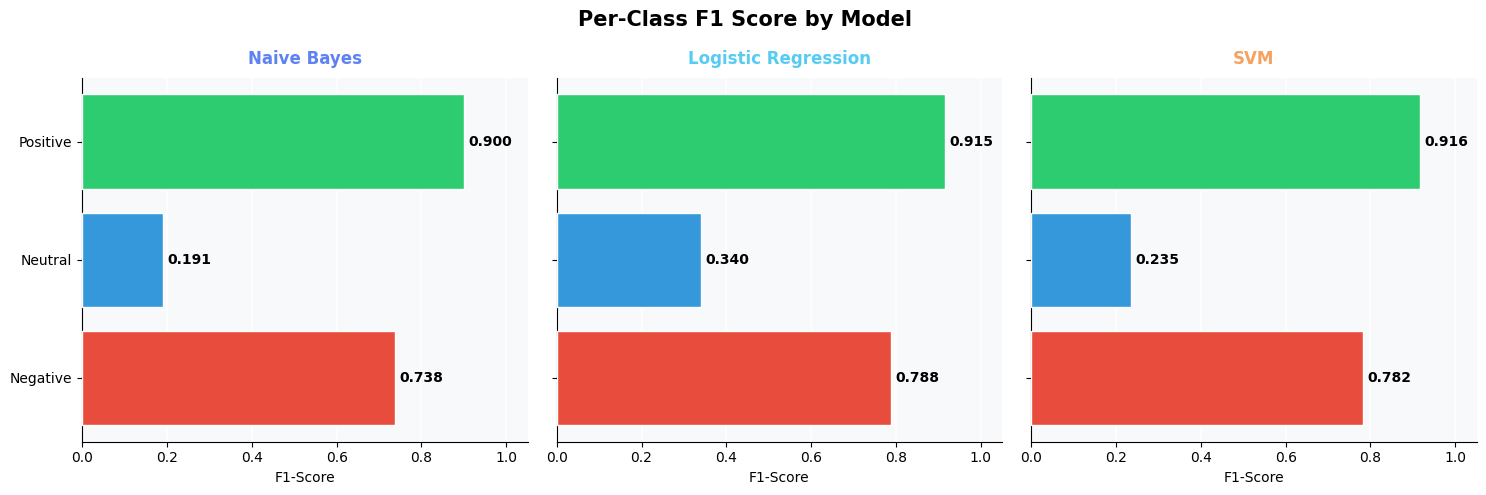

In [11]:
classes = ['Negative', 'Neutral', 'Positive']
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.suptitle('Per-Class F1 Score by Model', fontsize=15, fontweight='bold')

for ax, (model_name, res), color in zip(axes, results.items(), MODEL_COLORS):
    f1s = f1_score(res['y_true'], res['y_pred'], labels=classes, average=None, zero_division=0)
    bar_colors = [COLORS[c] for c in classes]
    bars = ax.barh(classes, f1s, color=bar_colors, edgecolor='white', zorder=3)
    ax.set_facecolor('#f8f9fa')
    ax.grid(axis='x', color='white', linewidth=1.2, zorder=2)
    ax.set_xlim(0, 1.05)
    ax.set_title(model_name, fontweight='bold', color=color, pad=10)
    ax.set_xlabel('F1-Score')
    for bar, val in zip(bars, f1s):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 10. Confusion Matrices

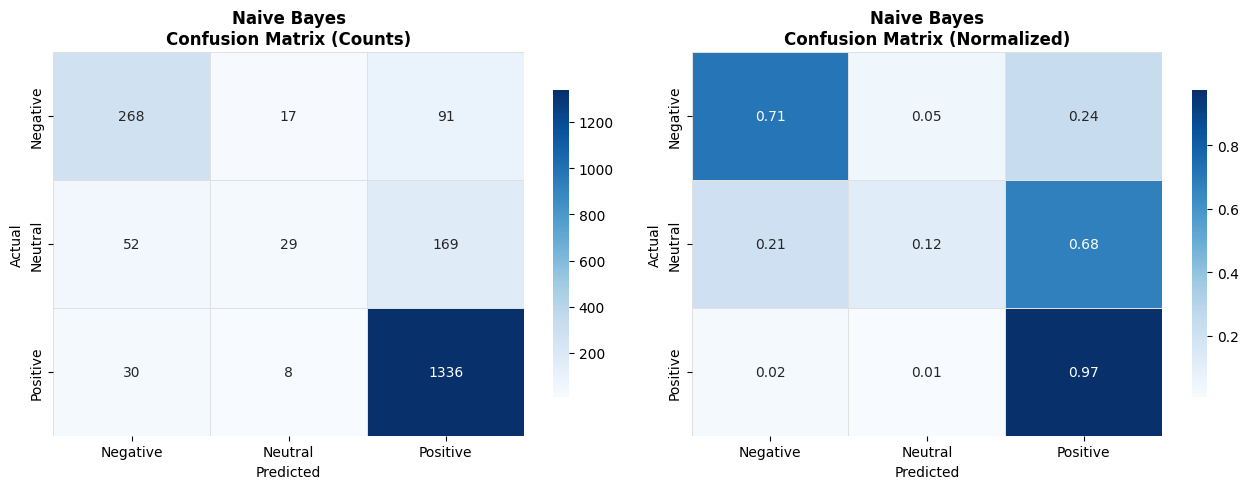

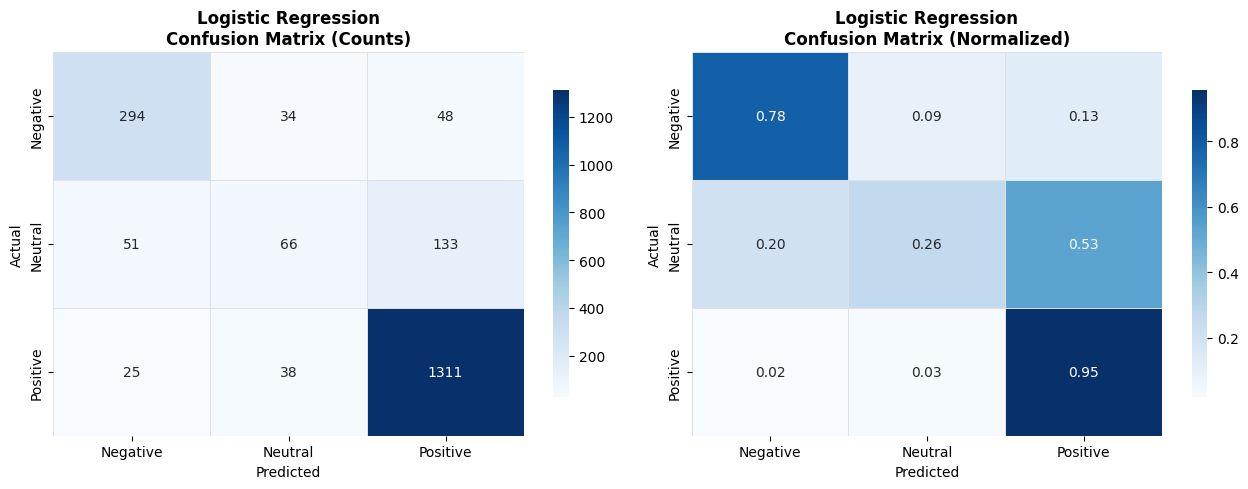

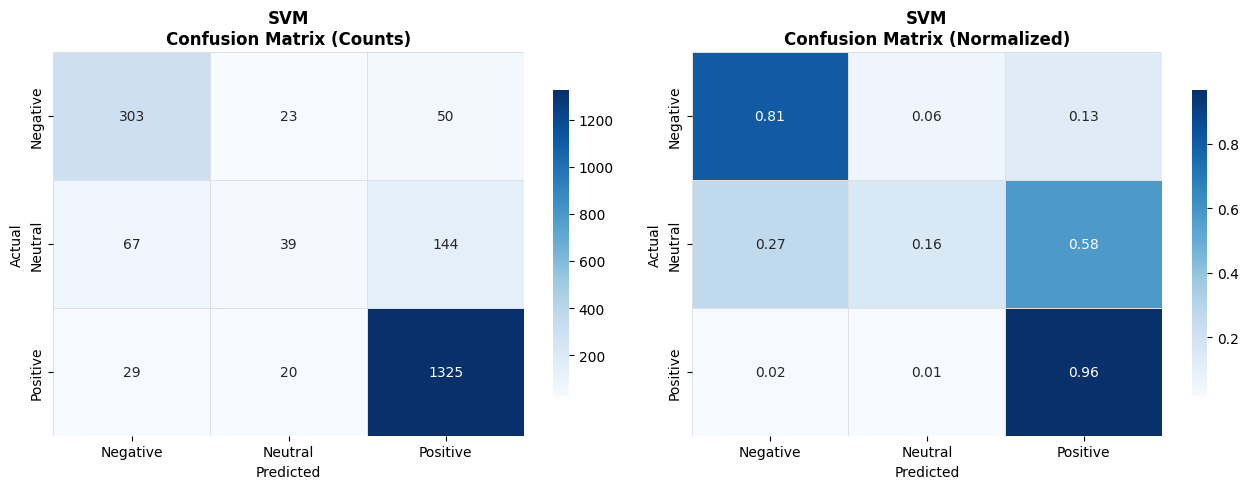

In [12]:
for model_name, res in results.items():
    labels_order = ['Negative', 'Neutral', 'Positive']
    cm = confusion_matrix(res['y_true'], res['y_pred'], labels=labels_order)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, data, fmt, suffix in zip(axes, [cm, cm_norm], ['.0f', '.2f'], ['(Counts)', '(Normalized)']):
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                    xticklabels=labels_order, yticklabels=labels_order,
                    linewidths=0.5, linecolor='#e0e0e0', ax=ax, cbar_kws={'shrink': 0.8})
        ax.set_title(f'{model_name}\nConfusion Matrix {suffix}', fontweight='bold')
        ax.set_ylabel('Actual')
        ax.set_xlabel('Predicted')
    plt.tight_layout()
    plt.show()

---
## 11. Classification Reports

In [13]:
for model_name, res in results.items():
    print(f'\n{"="*55}')
    print(f'  {model_name}')
    print(f'{"="*55}')
    print(classification_report(res['y_true'], res['y_pred'], zero_division=0))


  Naive Bayes
              precision    recall  f1-score   support

    Negative       0.77      0.71      0.74       376
     Neutral       0.54      0.12      0.19       250
    Positive       0.84      0.97      0.90      1374

    accuracy                           0.82      2000
   macro avg       0.71      0.60      0.61      2000
weighted avg       0.79      0.82      0.78      2000


  Logistic Regression
              precision    recall  f1-score   support

    Negative       0.79      0.78      0.79       376
     Neutral       0.48      0.26      0.34       250
    Positive       0.88      0.95      0.91      1374

    accuracy                           0.84      2000
   macro avg       0.72      0.67      0.68      2000
weighted avg       0.81      0.84      0.82      2000


  SVM
              precision    recall  f1-score   support

    Negative       0.76      0.81      0.78       376
     Neutral       0.48      0.16      0.23       250
    Positive       0.87      0

---
## 12. Summary & Conclusion

In [14]:
best = comparison_df['F1-Score'].idxmax()
print('MODEL COMPARISON SUMMARY')
print('='*55)
print(comparison_df.to_string())
print('='*55)
print(f'\nBest Model : {best}')
print(f'F1-Score   : {comparison_df.loc[best, "F1-Score"]:.4f}')
print(f'Accuracy   : {comparison_df.loc[best, "Accuracy"]:.4f}')
print()
print('Sentiment Distribution in Sample:')
for label in ['Positive', 'Neutral', 'Negative']:
    cnt = df['sentiment'].value_counts().get(label, 0)
    print(f'  {label:10s}: {cnt:5,}  ({cnt/len(df)*100:.1f}%)')

MODEL COMPARISON SUMMARY
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Naive Bayes            0.8165     0.7862  0.8165    0.7807
Logistic Regression    0.8355     0.8128  0.8355    0.8192
SVM                    0.8335     0.8015  0.8335    0.8057

Best Model : Logistic Regression
F1-Score   : 0.8192
Accuracy   : 0.8355

Sentiment Distribution in Sample:
  Positive  : 6,868  (68.7%)
  Neutral   : 1,251  (12.5%)
  Negative  : 1,881  (18.8%)
